In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/MovieData.csv")
df.head()

/tmp/ipykernel_28979/1623633204.py:1: DtypeWarning: Columns (28,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/MovieData.csv")


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,tmdb_music,tmdb_mystery,tmdb_romance,tmdb_science fiction,tmdb_thriller,tmdb_tv movie,tmdb_war,tmdb_western,imdb_reality-tv,imdb_adult
0,"1\n [static crackling]\n [man] In life,\n they...",#AMFAD: All My Friends Are Dead (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
1,"(MULTICOM JINGLE)\n (OMINOUS MUSIC)\n Hey, eve...",#Followme (2019),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
2,That was incredible.\n How did you get to be\n...,#Horror (2015),NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,...,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
3,(upbeat music)\n (audience cheering\n and appl...,#IMomSoHard Live (2019),NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1\n 'Feminism!'\n 'The trending word on all\n ...,#MenToo (2023),NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['filtered_genre'] = df.apply(lambda row: next(iter([col.replace('genre_', '') for col in df.columns if row[col] == 1 and "imdb" in col]), None), axis=1)



print(df[['filtered_genre']])


      filtered_genre
0        imdb_horror
1        imdb_horror
2         imdb_crime
3        imdb_comedy
4        imdb_comedy
...              ...
38158     imdb_drama
38159     imdb_drama
38160    imdb_action
38161    imdb_action
38162    imdb_action

[38163 rows x 1 columns]


In [4]:
from collections import Counter

Counter(df['filtered_genre'])

Counter({'imdb_drama': 7806,
         'imdb_comedy': 7690,
         'imdb_action': 5764,
         'imdb_documentary': 2891,
         'imdb_crime': 2780,
         'imdb_animation': 1581,
         None: 1417,
         'imdb_adventure': 1348,
         'imdb_biography': 1259,
         'imdb_history': 1259,
         'imdb_horror': 1148,
         'imdb_family': 726,
         'imdb_thriller': 456,
         'imdb_short': 365,
         'imdb_fantasy': 243,
         'imdb_romance': 230,
         'imdb_sci-fi': 213,
         'imdb_war': 181,
         'imdb_mystery': 138,
         'imdb_sport': 135,
         'imdb_talk-show': 107,
         'imdb_musical': 107,
         'imdb_id': 105,
         'imdb_western': 59,
         'imdb_music': 50,
         'imdb_news': 38,
         'imdb_film-noir': 25,
         'imdb_reality-tv': 24,
         'imdb_game-show': 17,
         'imdb_adult': 1})

In [5]:
genre_to_keep = ['imdb_drama','imdb_comedy','imdb_action','imdb_documentary']
columns_to_keep = ['Script','filtered_genre']

In [6]:
df_filtered = df.loc[df['filtered_genre'].isin(genre_to_keep)]

Counter(df_filtered['filtered_genre'])


Counter({'imdb_drama': 7806,
         'imdb_comedy': 7690,
         'imdb_action': 5764,
         'imdb_documentary': 2891})

In [7]:
df_filtered = df_filtered[columns_to_keep]

In [8]:
df_filtered= df_filtered.reset_index(drop=True)
df_filtered.head()

,Script,filtered_genre
0,(upbeat music)\n (audience cheering\n and appl...,imdb_comedy
1,1\n 'Feminism!'\n 'The trending word on all\n ...,imdb_comedy
2,"1\n Hey, Luni.\n - Hello.\n - Morning.\n Are y...",imdb_drama
3,"-""Lewis Hamilton""\n -My amibition is to get to...",imdb_documentary
4,"1\n Yes, everything is ready.\n - Oh, my God!\...",imdb_comedy


In [9]:
X_train,X_test , y_train,y_test = train_test_split(df_filtered['Script'],df_filtered['filtered_genre'],test_size=0.2,random_state=0)

In [10]:
model = make_pipeline(CountVectorizer(ngram_range = (2,2)), MultinomialNB())

In [11]:
model.fit(X_train, y_train)
#model.fit(X_train, y_train, multinomialnb__sample_weight=sample_weights)

y_pred = model.predict(X_test)

print(f"Features dimension: {len(X_train), len(model[0].vocabulary_)}")
print("Classification Report:\n", classification_report(y_test, y_pred))

: 

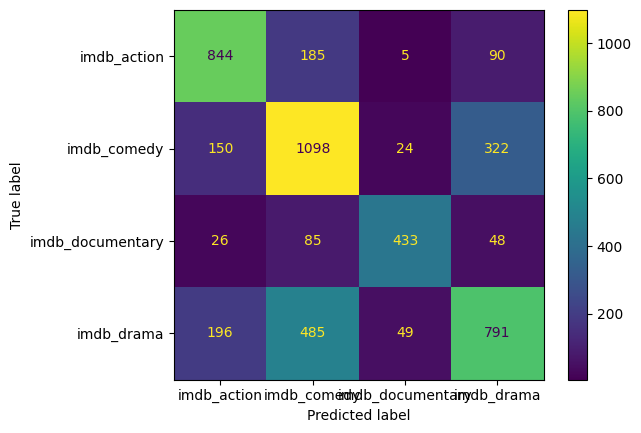

In [56]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
plt.show()